# 02. レース分析 (Race Analysis)

このノートブックでは、レース条件と結果の関係を分析します。

## 目次
1. セットアップ
2. レース条件別の分析
3. 競馬場別の分析
4. 距離・コース別の分析
5. 馬場状態の影響分析
6. 人気と着順の関係

## 1. セットアップ

In [5]:
# 必要なライブラリのインポート
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from google.cloud import bigquery
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings('ignore')

# フォントキャッシュを再構築して日本語フォントを認識させる
font_manager._load_fontmanager(try_read_cache=False)

# プロット設定（スタイルを先に適用）
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# 日本語フォント設定（スタイル適用後に設定することが重要）
plt.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False

# seabornのフォント設定も上書き
sns.set(font='IPAexGothic')

# 表示設定
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# 環境変数の読み込み
load_dotenv()
PROJECT_ID = os.environ.get('GCP_PROJECT_ID')
client = bigquery.Client(project=PROJECT_ID)

print(f'Python: {sys.executable}')
print(f'Matplotlib font: {plt.rcParams["font.family"]}')
print(f'Project ID: {PROJECT_ID}')
print('Setup complete!')

Python: /Users/michika_maruyama/Desktop/keiba_prediction/venv/bin/python
Matplotlib font: ['IPAexGothic']
Project ID: keiba-prediction-1768734113
Setup complete!


In [6]:
# 競馬場コードのマッピング
VENUE_CODES = {
    '01': '札幌', '02': '函館', '03': '福島', '04': '新潟', '05': '東京',
    '06': '中山', '07': '中京', '08': '京都', '09': '阪神', '10': '小倉'
}

# コースタイプのマッピング
COURSE_TYPES = {
    '1': '芝', '2': 'ダート', '3': '障害'
}

# 馬場状態のマッピング
TRACK_CONDITIONS = {
    '1': '良', '2': '稍重', '3': '重', '4': '不良'
}

## 2. レース条件別の分析

In [7]:
# レース条件別の統計を取得
query_race_conditions = f"""
SELECT 
    ri.venue_code,
    ri.course_type,
    ri.distance,
    ri.track_condition,
    ri.num_horses,
    COUNT(DISTINCT ri.race_id) as race_count
FROM `{PROJECT_ID}.raw.race_info` ri
WHERE ri.race_date >= '2020-01-01'
GROUP BY venue_code, course_type, distance, track_condition, num_horses
ORDER BY race_count DESC
LIMIT 10000
"""

df_conditions = client.query(query_race_conditions).to_dataframe()
print(f'レコード数: {len(df_conditions)}')
df_conditions.head()

レコード数: 759


,venue_code,course_type,distance,track_condition,num_horses,race_count
0,06,dirt,1800,None,0,84
1,06,dirt,1200,None,0,67
2,06,dirt,1200,None,16,62
3,05,dirt,1600,None,0,57
4,09,dirt,1800,None,0,56


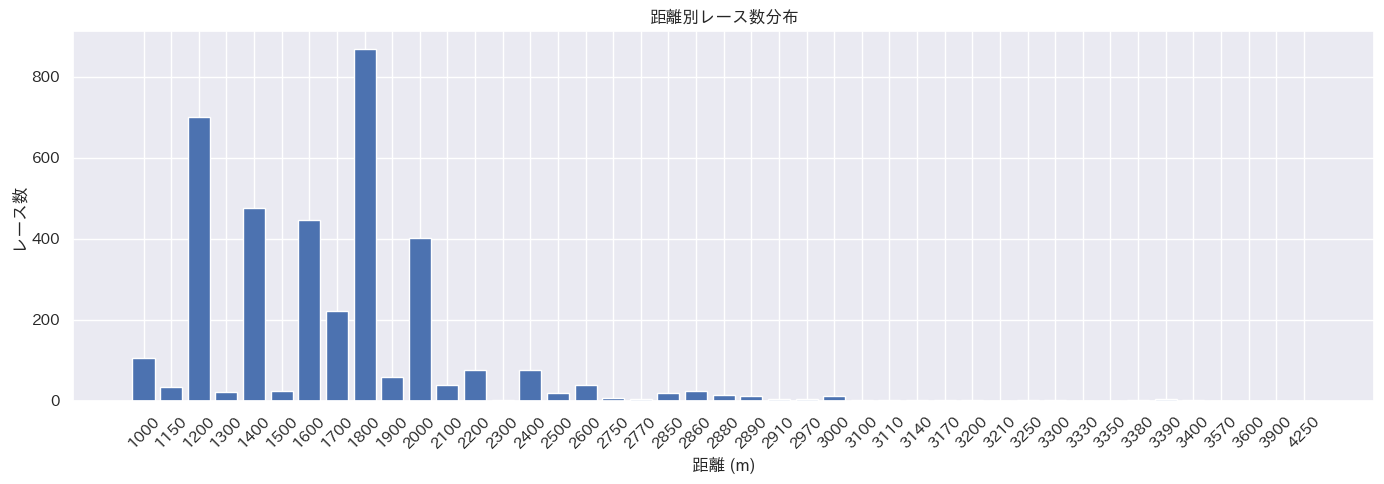


=== 距離別レース数（上位10） ===
distance
1800    868
1200    701
1400    475
1600    446
2000    403
1700    222
1000    105
2400     77
2200     77
1900     60
Name: race_count, dtype: Int64


In [8]:
# 距離分布の可視化
plt.figure(figsize=(14, 5))

# 距離ごとのレース数
distance_counts = df_conditions.groupby('distance')['race_count'].sum().sort_index()

plt.bar(distance_counts.index.astype(str), distance_counts.values)
plt.xlabel('距離 (m)')
plt.ylabel('レース数')
plt.title('距離別レース数分布')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\n=== 距離別レース数（上位10） ===')
print(distance_counts.sort_values(ascending=False).head(10))

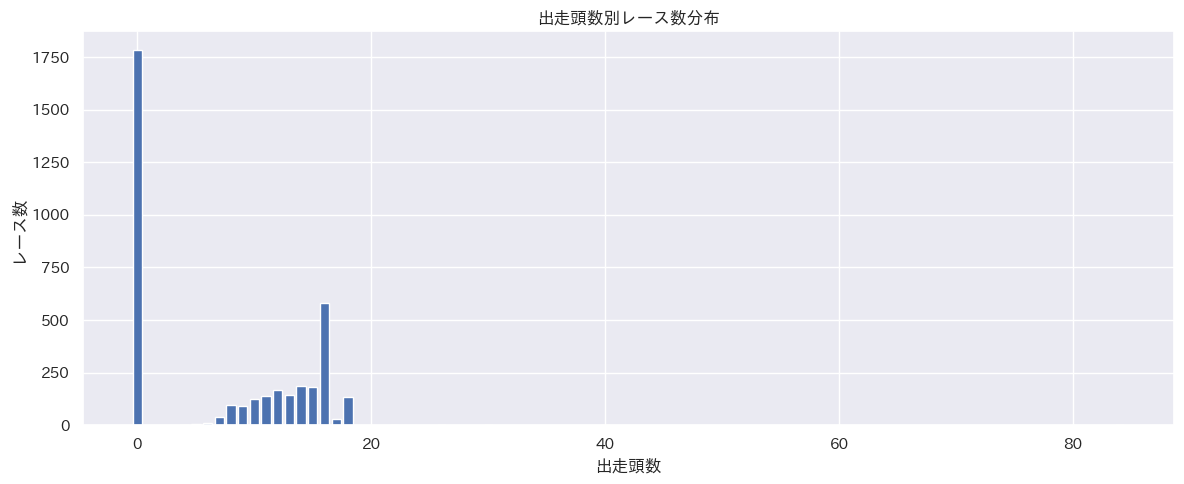


平均出走頭数: 7.1頭


In [12]:
# 出走頭数の分布
plt.figure(figsize=(12, 5))

num_horses_counts = df_conditions.groupby('num_horses')['race_count'].sum().sort_index()

plt.bar(num_horses_counts.index, num_horses_counts.values)
plt.xlabel('出走頭数')
plt.ylabel('レース数')
plt.title('出走頭数別レース数分布')
plt.tight_layout()
plt.show()

print(f'\n平均出走頭数: {np.sum(num_horses_counts.index * num_horses_counts.values) / num_horses_counts.sum():.1f}頭')

## 3. 競馬場別の分析

In [13]:
# 競馬場別のレース数と平均出走頭数
query_venue_stats = f"""
SELECT 
    ri.venue_code,
    COUNT(DISTINCT ri.race_id) as race_count,
    AVG(ri.num_horses) as avg_num_horses,
    AVG(ri.distance) as avg_distance
FROM `{PROJECT_ID}.raw.race_info` ri
WHERE ri.race_date >= '2020-01-01'
    AND ri.venue_code IN ('01', '02', '03', '04', '05', '06', '07', '08', '09', '10')
GROUP BY venue_code
ORDER BY race_count DESC
"""

df_venue = client.query(query_venue_stats).to_dataframe()
df_venue['venue_name'] = df_venue['venue_code'].map(VENUE_CODES)

print('=== 競馬場別統計 ===')
df_venue

=== 競馬場別統計 ===


,venue_code,race_count,avg_num_horses,avg_distance,venue_name
0,06,588,7.68,1698.47,中山
1,05,528,7.32,1701.52,東京
2,09,504,6.98,1672.62,阪神
3,07,492,6.97,1668.35,中京
4,04,384,7.57,1693.96,新潟
5,08,372,6.59,1676.21,京都
6,10,348,7.20,1704.17,小倉
7,03,216,7.11,1669.07,福島
8,01,204,6.58,1615.20,札幌
9,02,120,4.79,1528.33,函館


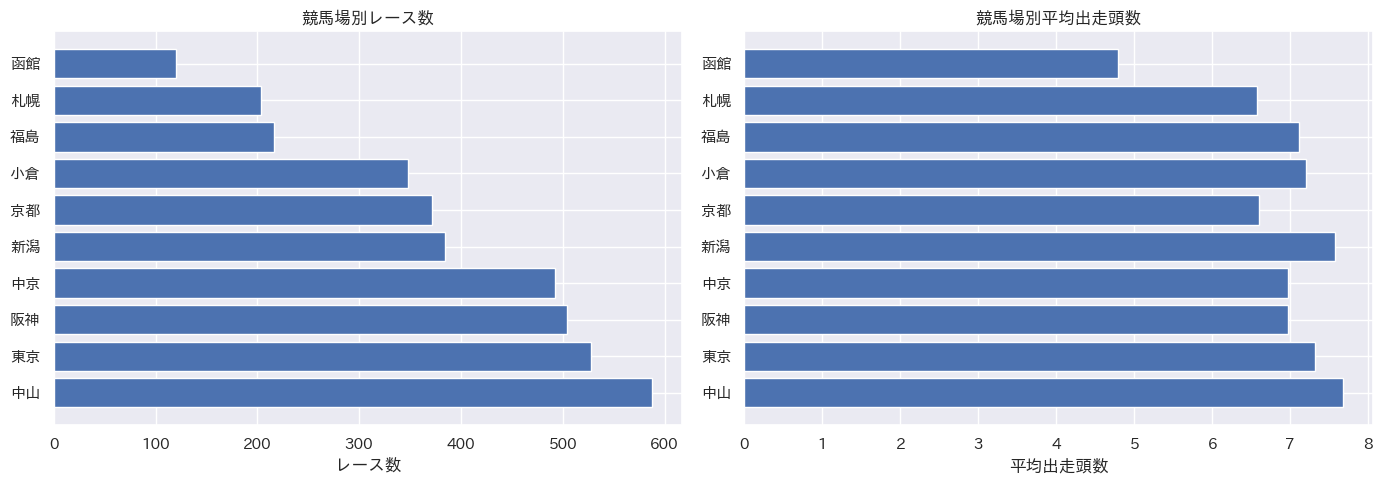

In [14]:
# 競馬場別レース数の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# レース数
axes[0].barh(df_venue['venue_name'], df_venue['race_count'])
axes[0].set_xlabel('レース数')
axes[0].set_title('競馬場別レース数')

# 平均出走頭数
axes[1].barh(df_venue['venue_name'], df_venue['avg_num_horses'])
axes[1].set_xlabel('平均出走頭数')
axes[1].set_title('競馬場別平均出走頭数')

plt.tight_layout()
plt.show()

## 4. 距離・コース別の分析

In [15]:
# コースタイプ別の距離分布
query_course_distance = f"""
SELECT 
    ri.course_type,
    ri.distance,
    COUNT(DISTINCT ri.race_id) as race_count
FROM `{PROJECT_ID}.raw.race_info` ri
WHERE ri.race_date >= '2020-01-01'
GROUP BY course_type, distance
ORDER BY course_type, distance
"""

df_course_dist = client.query(query_course_distance).to_dataframe()
df_course_dist['course_name'] = df_course_dist['course_type'].map(COURSE_TYPES)
df_course_dist.head()

,course_type,distance,race_count,course_name
0,dirt,1000,77,NaN
1,dirt,1150,35,NaN
2,dirt,1200,370,NaN
3,dirt,1300,22,NaN
4,dirt,1400,302,NaN


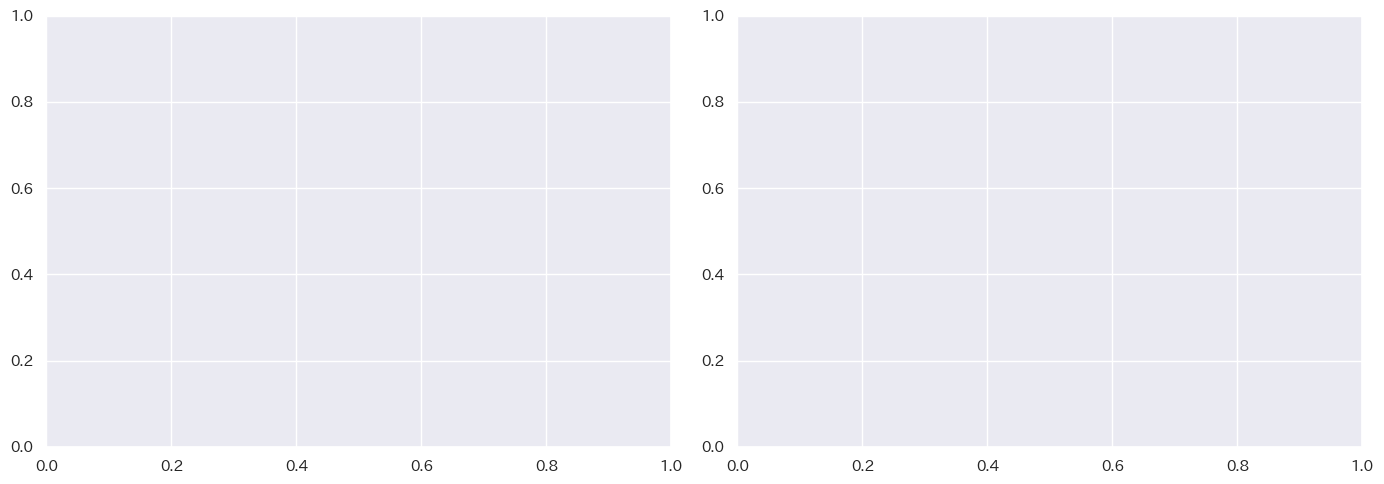

In [16]:
# コースタイプ別の距離分布を可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, course_type in enumerate(['芝', 'ダート']):
    data = df_course_dist[df_course_dist['course_name'] == course_type]
    if len(data) > 0:
        axes[i].bar(data['distance'].astype(str), data['race_count'])
        axes[i].set_xlabel('距離 (m)')
        axes[i].set_ylabel('レース数')
        axes[i].set_title(f'{course_type}コース - 距離別レース数')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [18]:
# 距離カテゴリの定義と分析
def categorize_distance(distance):
    if distance < 1400:
        return 'スプリント'
    elif distance < 1800:
        return 'マイル'
    elif distance < 2200:
        return '中距離'
    else:
        return '長距離'

df_course_dist['distance_category'] = df_course_dist['distance'].apply(categorize_distance)

# 距離カテゴリ別集計
category_summary = df_course_dist.groupby(['course_name', 'distance_category'])['race_count'].sum().unstack()
print('=== コースタイプ x 距離カテゴリ ===')
category_summary

=== コースタイプ x 距離カテゴリ ===


distance_category
course_name


## 5. 馬場状態の影響分析

In [19]:
# 馬場状態別の統計
query_track_condition = f"""
SELECT 
    ri.course_type,
    ri.track_condition,
    COUNT(DISTINCT ri.race_id) as race_count
FROM `{PROJECT_ID}.raw.race_info` ri
WHERE ri.race_date >= '2020-01-01'
    AND ri.track_condition IS NOT NULL
GROUP BY course_type, track_condition
ORDER BY course_type, track_condition
"""

df_track = client.query(query_track_condition).to_dataframe()
df_track['course_name'] = df_track['course_type'].map(COURSE_TYPES)
df_track

,course_type,track_condition,race_count,course_name


In [20]:
# 馬場状態の分布を可視化
pivot_track = df_track.pivot(index='track_condition', columns='course_name', values='race_count')

pivot_track.plot(kind='bar', figsize=(10, 5))
plt.xlabel('馬場状態')
plt.ylabel('レース数')
plt.title('コースタイプ別馬場状態の分布')
plt.legend(title='コースタイプ')
plt.tight_layout()
plt.show()

TypeError: no numeric data to plot

## 6. 人気と着順の関係

In [21]:
# 人気別の着順分布
query_popularity = f"""
SELECT 
    hr.base_popularity as popularity,
    COUNT(*) as total,
    SUM(CASE WHEN hr.goal_position = 1 THEN 1 ELSE 0 END) as win_count,
    SUM(CASE WHEN hr.goal_position <= 3 THEN 1 ELSE 0 END) as place_count,
    AVG(hr.goal_position) as avg_position
FROM `{PROJECT_ID}.raw.horse_results` hr
WHERE hr.base_popularity IS NOT NULL
    AND hr.base_popularity > 0
    AND hr.base_popularity <= 18
    AND hr.goal_position IS NOT NULL
    AND hr.goal_position > 0
GROUP BY popularity
ORDER BY popularity
"""

try:
    df_popularity = client.query(query_popularity).to_dataframe()
    df_popularity['win_rate'] = df_popularity['win_count'] / df_popularity['total'] * 100
    df_popularity['place_rate'] = df_popularity['place_count'] / df_popularity['total'] * 100
    
    print('=== 人気別勝率・複勝率 ===')
    df_popularity
except Exception as e:
    print(f'Error: {e}')
    print('\n注: horse_resultsテーブルのカラム名を確認してください')

=== 人気別勝率・複勝率 ===


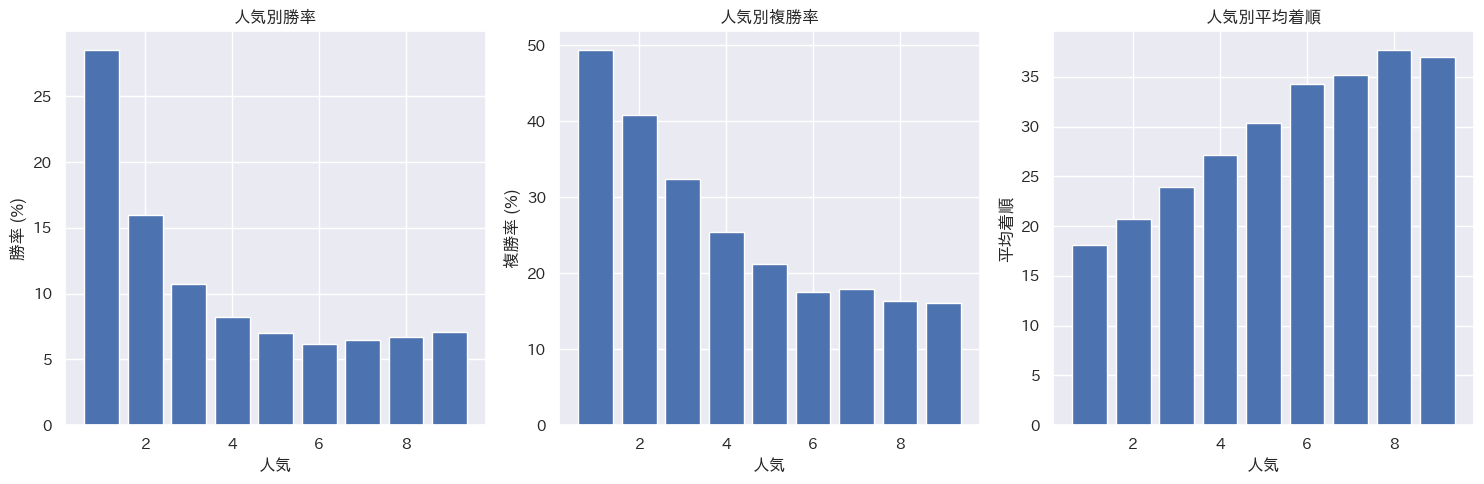

In [22]:
# 人気と勝率・複勝率の可視化
try:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 勝率
    axes[0].bar(df_popularity['popularity'], df_popularity['win_rate'])
    axes[0].set_xlabel('人気')
    axes[0].set_ylabel('勝率 (%)')
    axes[0].set_title('人気別勝率')
    
    # 複勝率
    axes[1].bar(df_popularity['popularity'], df_popularity['place_rate'])
    axes[1].set_xlabel('人気')
    axes[1].set_ylabel('複勝率 (%)')
    axes[1].set_title('人気別複勝率')
    
    # 平均着順
    axes[2].bar(df_popularity['popularity'], df_popularity['avg_position'])
    axes[2].set_xlabel('人気')
    axes[2].set_ylabel('平均着順')
    axes[2].set_title('人気別平均着順')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error: {e}')

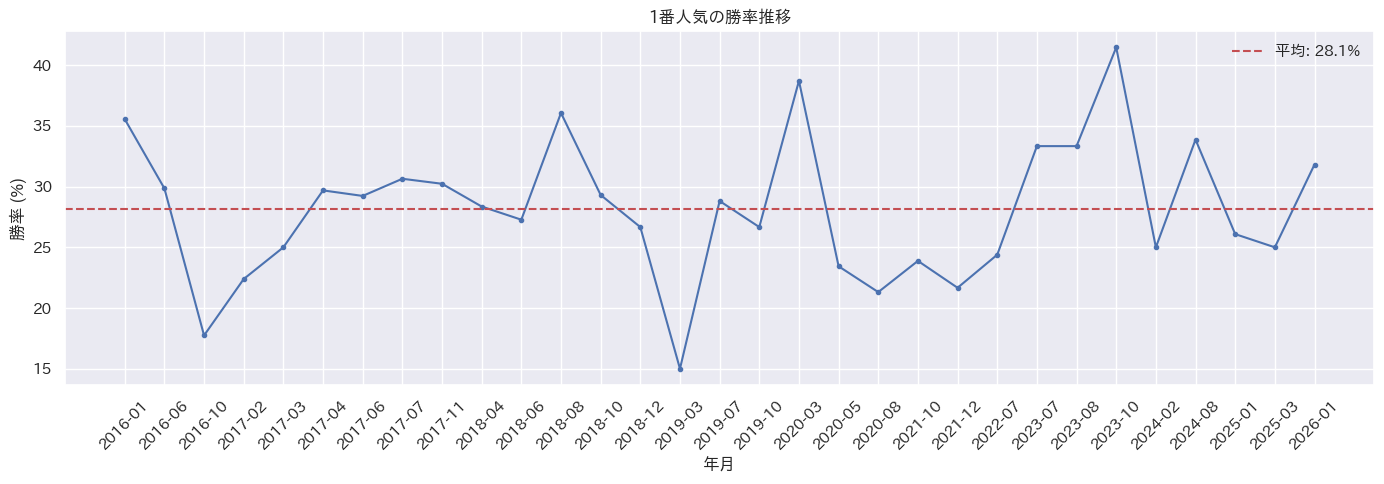


1番人気の平均勝率: 28.1%
勝率の標準偏差: 5.8%


In [23]:
# 1番人気の勝率推移（月別）
query_favorite_monthly = f"""
SELECT 
    FORMAT_DATE('%Y-%m', ri.race_date) as year_month,
    COUNT(*) as total,
    SUM(CASE WHEN hr.goal_position = 1 THEN 1 ELSE 0 END) as win_count
FROM `{PROJECT_ID}.raw.horse_results` hr
JOIN `{PROJECT_ID}.raw.race_info` ri ON hr.race_id = ri.race_id
WHERE hr.base_popularity = 1
    AND hr.goal_position IS NOT NULL
    AND hr.goal_position > 0
GROUP BY year_month
ORDER BY year_month
"""

try:
    df_favorite = client.query(query_favorite_monthly).to_dataframe()
    df_favorite['win_rate'] = df_favorite['win_count'] / df_favorite['total'] * 100
    
    plt.figure(figsize=(14, 5))
    plt.plot(df_favorite['year_month'], df_favorite['win_rate'], marker='o', markersize=3)
    plt.axhline(y=df_favorite['win_rate'].mean(), color='r', linestyle='--', label=f'平均: {df_favorite["win_rate"].mean():.1f}%')
    plt.xlabel('年月')
    plt.ylabel('勝率 (%)')
    plt.title('1番人気の勝率推移')
    plt.legend()
    # X軸のラベルを間引く
    n = len(df_favorite)
    step = max(1, n // 20)
    plt.xticks(range(0, n, step), df_favorite['year_month'].iloc[::step], rotation=45)
    plt.tight_layout()
    plt.show()
    
    print(f'\n1番人気の平均勝率: {df_favorite["win_rate"].mean():.1f}%')
    print(f'勝率の標準偏差: {df_favorite["win_rate"].std():.1f}%')
except Exception as e:
    print(f'Error: {e}')

## まとめ

このノートブックでは以下の分析を行いました：

1. **レース条件**: 距離分布、出走頭数の傾向
2. **競馬場別分析**: 各競馬場のレース数と特徴
3. **距離・コース別分析**: 芝/ダートの距離分布、距離カテゴリ
4. **馬場状態の影響**: 馬場状態の出現頻度
5. **人気と着順の関係**: 人気別勝率・複勝率、1番人気の勝率推移

### 主な発見
- 1番人気の勝率は約30%前後で安定
- 人気が下がるほど勝率・複勝率は下がる傾向
- 競馬場によって開催頻度が異なる

### 次のステップ
- `03_horse_analysis.ipynb`: 馬の成績分析
- `04_feature_correlation.ipynb`: 特徴量の相関分析